<a href="https://colab.research.google.com/github/Pinkraaaa/Intro-to-AI-Group-9/blob/middy_knn/Intro_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/Pinkraaaa/Intro-to-AI-Group-9.git
%cd Intro-to-AI-Group-9
!unzip -q Potato_Test.zip
!unzip -q Potato_Train.zip
!unzip -q Potato_Validate.zip

Cloning into 'Intro-to-AI-Group-9'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 42 (delta 12), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 61.91 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Intro-to-AI-Group-9


In [4]:
import torch
print("GPU available:", torch.cuda.is_available())

import os
for split in ["Train", "Valid", "Test"]:
    print(f"\n{split}:")
    for cls in sorted(os.listdir(split)):
        print(f"  {cls}: {len(os.listdir(os.path.join(split, cls)))} images")

GPU available: True

Train:
  Potato___Early_blight: 300 images
  Potato___Late_blight: 300 images
  Potato___healthy: 300 images

Valid:
  Potato___Early_blight: 100 images
  Potato___Late_blight: 100 images
  Potato___healthy: 100 images

Test:
  Potato___Early_blight: 100 images
  Potato___Late_blight: 100 images
  Potato___healthy: 100 images


In [5]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import numpy as np

# ---- Directories (match the repo structure exactly) ----
train_dir = "Train"
val_dir = "Valid"
test_dir = "Test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Deterministic preprocessing for embeddings (no augmentation) ----
embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats -
                          std=[0.229, 0.224, 0.225]),    # what the pretrained
                                                          # backbone expects
])

# ---- Load datasets (shuffle=False so order matches dataset.samples,
#      which is what lets us recover filepaths for similarity search) ----
train_dataset = datasets.ImageFolder(train_dir, transform=embedding_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=embedding_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=embedding_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)
assert class_names == val_dataset.classes == test_dataset.classes, \
    "Class ordering mismatch between splits - check folder names match exactly"

# ---- Build the pretrained feature extractor (MobileNetV2 via torchvision) ----
backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
backbone.classifier = nn.Identity()   # remove the classification head
backbone.eval()
backbone.to(device)


def extract_embeddings(loader, dataset, split_name):
    """Runs every image through the backbone, returns embeddings + labels + filepaths."""
    all_features, all_labels = [], []
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            features = backbone(images)          # shape: (batch, 1280)
            features = features.mean(dim=[2, 3]) if features.dim() > 2 else features
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
            print(f"[{split_name}] batch {batch_idx + 1}/{len(loader)}")

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)
    # dataset.samples is a list of (filepath, label_idx) in the SAME order
    # DataLoader iterated them in, since shuffle=False
    filepaths = [s[0] for s in dataset.samples]
    return X, y, filepaths


# ---- Extract for all three splits ----
X_train, y_train, fp_train = extract_embeddings(train_loader, train_dataset, "Train")
X_val, y_val, fp_val = extract_embeddings(val_loader, val_dataset, "Valid")
X_test, y_test, fp_test = extract_embeddings(test_loader, test_dataset, "Test")

print(f"\nTrain: {X_train.shape} | Valid: {X_val.shape} | Test: {X_test.shape}")

# ---- Save everything ----
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_val.npy", X_val)
np.save("y_val.npy", y_val)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

with open("class_names.txt", "w") as f:
    f.write("\n".join(class_names))
with open("train_filepaths.txt", "w") as f:
    f.write("\n".join(fp_train))
with open("val_filepaths.txt", "w") as f:
    f.write("\n".join(fp_val))
with open("test_filepaths.txt", "w") as f:
    f.write("\n".join(fp_test))

print("\nSaved: X_train.npy, y_train.npy, X_val.npy, y_val.npy, X_test.npy, "
      "y_test.npy, class_names.txt, train_filepaths.txt, val_filepaths.txt, "
      "test_filepaths.txt")

Using device: cuda
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 154MB/s]


[Train] batch 1/29
[Train] batch 2/29
[Train] batch 3/29
[Train] batch 4/29
[Train] batch 5/29
[Train] batch 6/29
[Train] batch 7/29
[Train] batch 8/29
[Train] batch 9/29
[Train] batch 10/29
[Train] batch 11/29
[Train] batch 12/29
[Train] batch 13/29
[Train] batch 14/29
[Train] batch 15/29
[Train] batch 16/29
[Train] batch 17/29
[Train] batch 18/29
[Train] batch 19/29
[Train] batch 20/29
[Train] batch 21/29
[Train] batch 22/29
[Train] batch 23/29
[Train] batch 24/29
[Train] batch 25/29
[Train] batch 26/29
[Train] batch 27/29
[Train] batch 28/29
[Train] batch 29/29
[Valid] batch 1/10
[Valid] batch 2/10
[Valid] batch 3/10
[Valid] batch 4/10
[Valid] batch 5/10
[Valid] batch 6/10
[Valid] batch 7/10
[Valid] batch 8/10
[Valid] batch 9/10
[Valid] batch 10/10
[Test] batch 1/10
[Test] batch 2/10
[Test] batch 3/10
[Test] batch 4/10
[Test] batch 5/10
[Test] batch 6/10
[Test] batch 7/10
[Test] batch 8/10
[Test] batch 9/10
[Test] batch 10/10

Train: (900, 1280) | Valid: (300, 1280) | Test: (300, 12

In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


def train_knn_classifier(X_train, y_train, n_neighbors=5, scale=True):
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean")
    knn.fit(X_train, y_train)
    return knn, scaler


def predict_knn(knn, scaler, X):
    if scaler is not None:
        X = scaler.transform(X)
    return knn.predict(X)


def build_similarity_index(X_train, scaler=None):
    if scaler is not None:
        X_train = scaler.transform(X_train)
    index = NearestNeighbors(metric="euclidean")
    index.fit(X_train)
    return index


def find_similar_leaves(index, query_embedding, k, X_train_filepaths, y_train,
                         class_names, scaler=None):
    query = query_embedding.reshape(1, -1)
    if scaler is not None:
        query = scaler.transform(query)
    distances, indices = index.kneighbors(query, n_neighbors=k)
    distances, indices = distances[0], indices[0]
    results = []
    for dist, idx in zip(distances, indices):
        results.append({
            "filepath": X_train_filepaths[idx],
            "label": class_names[y_train[idx]],
            "distance": float(dist),
        })
    return results


In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)


def evaluate_predictions(y_true, y_pred, class_names):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "report": classification_report(
            y_true, y_pred, target_names=class_names, zero_division=0
        ),
    }
    return metrics


def print_metrics(name, metrics):
    print(f"\n=== {name} ===")
    print(f"Accuracy:            {metrics['accuracy']:.3f}")
    print(f"Precision (macro):   {metrics['precision_macro']:.3f}")
    print(f"Recall (macro):      {metrics['recall_macro']:.3f}")
    print(f"F1-score (macro):    {metrics['f1_macro']:.3f}")
    print("\nPer-class report:")
    print(metrics["report"])


def compare_models(knn_metrics, cnn_metrics, class_names):
    print(f"\n{'Metric':<22}{'KNN':>10}{'CNN':>10}")
    print("-" * 42)
    for key, label in [
        ("accuracy", "Accuracy"),
        ("precision_macro", "Precision (macro)"),
        ("recall_macro", "Recall (macro)"),
        ("f1_macro", "F1-score (macro)"),
    ]:
        print(f"{label:<22}{knn_metrics[key]:>10.3f}{cnn_metrics[key]:>10.3f}")
    print("\nKNN confusion matrix:")
    print(knn_metrics["confusion_matrix"])
    print("\nCNN confusion matrix:")
    print(cnn_metrics["confusion_matrix"])


def plot_confusion_matrices(knn_metrics, cnn_metrics, class_names, save_path=None):
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, metrics, title in [
        (axes[0], knn_metrics, "KNN"),
        (axes[1], cnn_metrics, "CNN"),
    ]:
        sns.heatmap(
            metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False,
        )
        ax.set_title(f"{title} Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved figure to {save_path}")
    else:
        plt.show()


In [8]:
import numpy as np

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
class_names = open("class_names.txt").read().splitlines()

print(f"Train: {X_train.shape[0]} | Valid: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Tune k on validation
k_values = [3, 5, 7, 9, 11]
best_k, best_f1 = None, -1
for k in k_values:
    knn, scaler = train_knn_classifier(X_train, y_train, n_neighbors=k)
    y_pred_val = predict_knn(knn, scaler, X_val)
    metrics = evaluate_predictions(y_val, y_pred_val, class_names)
    print(f"k={k:<3} val accuracy={metrics['accuracy']:.3f}  val F1={metrics['f1_macro']:.3f}")
    if metrics["f1_macro"] > best_f1:
        best_k, best_f1 = k, metrics["f1_macro"]

print(f"\nBest k: {best_k} (F1={best_f1:.3f})")

# Final KNN on best k, evaluate once on test
knn, scaler = train_knn_classifier(X_train, y_train, n_neighbors=best_k)
y_pred_test = predict_knn(knn, scaler, X_test)
knn_metrics = evaluate_predictions(y_test, y_pred_test, class_names)
print_metrics(f"KNN (k={best_k}) - TEST SET", knn_metrics)

np.save("y_pred_knn_test.npy", y_pred_test)

Train: 900 | Valid: 300 | Test: 300
k=3   val accuracy=0.970  val F1=0.970
k=5   val accuracy=0.973  val F1=0.973
k=7   val accuracy=0.973  val F1=0.973
k=9   val accuracy=0.970  val F1=0.970
k=11  val accuracy=0.970  val F1=0.970

Best k: 5 (F1=0.973)

=== KNN (k=5) - TEST SET ===
Accuracy:            0.970
Precision (macro):   0.970
Recall (macro):      0.970
F1-score (macro):    0.970

Per-class report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.99      0.98       100
 Potato___Late_blight       0.98      0.93      0.95       100
     Potato___healthy       0.97      0.99      0.98       100

             accuracy                           0.97       300
            macro avg       0.97      0.97      0.97       300
         weighted avg       0.97      0.97      0.97       300



In [9]:
train_filepaths = open("train_filepaths.txt").read().splitlines()
test_filepaths = open("test_filepaths.txt").read().splitlines()

index = build_similarity_index(X_train, scaler)
query_idx = 0
results = find_similar_leaves(index, X_test[query_idx], k=5,
                               X_train_filepaths=train_filepaths,
                               y_train=y_train, class_names=class_names, scaler=scaler)
print(f"Query: {test_filepaths[query_idx]} (true: {class_names[y_test[query_idx]]})")
for r in results:
    print(f"  {r['filepath']:<30} label={r['label']:<25} dist={r['distance']:.2f}")

Query: Test/Potato___Early_blight/034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early.B 7136.JPG (true: Potato___Early_blight)
  Train/Potato___Early_blight/ffef8a3b-3e8a-4c24-a27e-64c41708f7a0___RS_Early.B 7132.JPG label=Potato___Early_blight     dist=36.58
  Train/Potato___Early_blight/dc6516c4-a74c-465f-85a1-55608ee518da___RS_Early.B 8843.JPG label=Potato___Early_blight     dist=36.88
  Train/Potato___Early_blight/bcf169b0-dea7-49eb-b976-4a2d1f36c574___RS_Early.B 7870.JPG label=Potato___Early_blight     dist=37.42
  Train/Potato___Early_blight/c74c801d-a6e5-44dc-a7e8-f3a5f39a300e___RS_Early.B 7864.JPG label=Potato___Early_blight     dist=37.56
  Train/Potato___Early_blight/c71ad6f9-6258-4602-84dc-ecf75296672c___RS_Early.B 7525.JPG label=Potato___Early_blight     dist=37.89


In [12]:
import numpy as np

y_test = np.load("y_test.npy")
class_names = open("class_names.txt").read().splitlines()
y_pred_knn = np.load("y_pred_knn_test.npy")
y_pred_cnn = np.load("/content/y_pred_cnn_test.npy")

knn_metrics = evaluate_predictions(y_test, y_pred_knn, class_names)
cnn_metrics = evaluate_predictions(y_test, y_pred_cnn, class_names)
compare_models(knn_metrics, cnn_metrics, class_names)


Metric                       KNN       CNN
------------------------------------------
Accuracy                   0.970     0.973
Precision (macro)          0.970     0.975
Recall (macro)             0.970     0.973
F1-score (macro)           0.970     0.974

KNN confusion matrix:
[[99  1  0]
 [ 4 93  3]
 [ 0  1 99]]

CNN confusion matrix:
[[ 96   4   0]
 [  0 100   0]
 [  0   4  96]]


Saved figure to knn_confusion_matrix.png


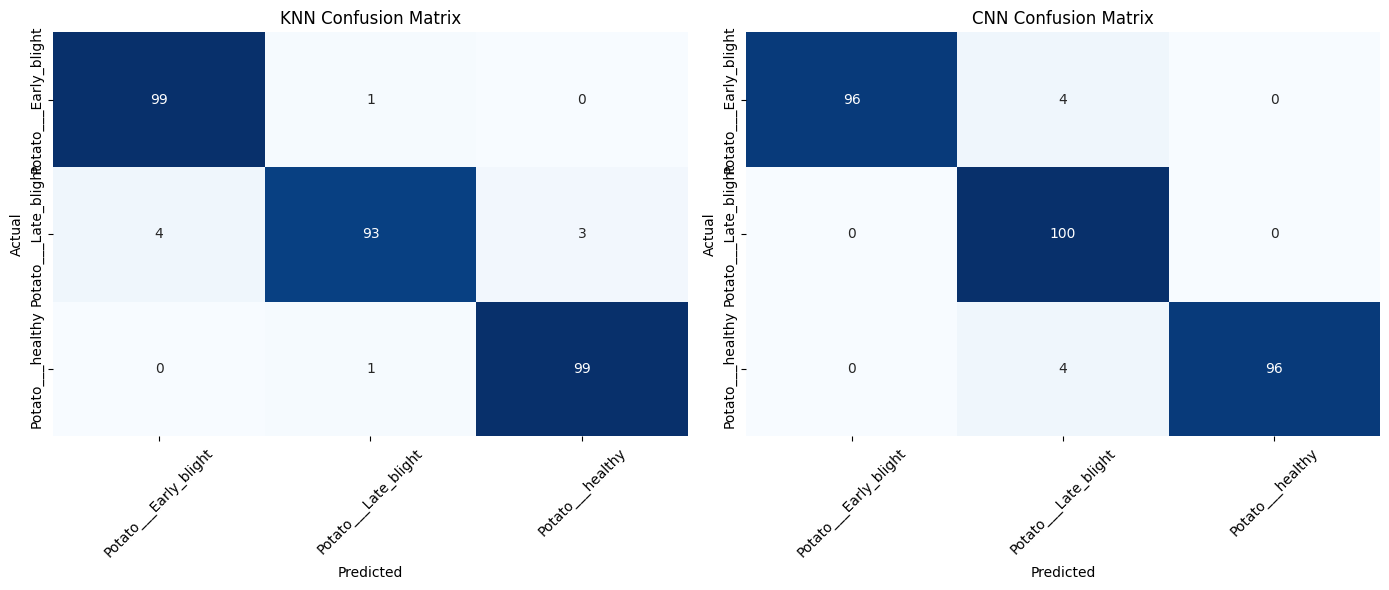

In [13]:
plot_confusion_matrices(knn_metrics, cnn_metrics, class_names, save_path="knn_confusion_matrix.png")